In [1]:
import scanpy as sc
#import session_info
import os
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import math
#from plotnine import *
#import scvi
import os


#import celltypist
#import scanpy
# verbosity: errors (0), warnings (1), info (2), hints (3)
%matplotlib inline
sc.settings.verbosity = 0




/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: 

In [2]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
#%matplotlib inline
sc.settings.figdir = "supp"
sc.settings.set_figure_params(dpi=50, dpi_save=300, facecolor="white", frameon=False, figsize=(18,18),
                              vector_friendly=True
                             )

# scRNA

In [3]:
PATH = '/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered'
adata=sc.read_h5ad(PATH)
adata_5k=adata[adata.obs["tech"]=="xenium"].copy()
del(adata)
import gc
gc.collect()


def remove_markers(LIST):
    try: 
        LIST = {key: [gene for gene in genes if gene in adata_5k.var_names] 
                           for key, genes in LIST.items()}
    except: 
        LIST =[gene for gene in LIST if gene in adata_5k.var_names]
    return LIST





In [4]:
sc.pp.normalize_total(adata_5k, target_sum=1e4)
sc.pp.log1p(adata_5k)

# AD

In [5]:
VMAX_PLOTS = 0.8
SPOT_SIZE=40


In [6]:
adata_5k_i=adata_5k[adata_5k.obs["disease_overall"]=="AD"]

In [7]:
AD_GENES_OT=  [
    "RUNX3",
    "FLG",
    "S100A9",
    "IL6R",
    "TNFSF4",
    "ID2",
    "CD207",
    "IL18RAP",
    "SATB1",
    "GLB1",
    "CD200R1",
    "KIAA1109",
    "IL7R",
    "CAMK4",
    "CDC42SE2",
    "SLC22A5",
    "ERGIC1",
    "TNF",
    "ATF6B",
    "AGER",
    "HLA-DRA",
    "TAGAP",
    "ZBTB10",
    "TRIB1",
    "IL2RA",
    "PRKCQ",
    "ADO",
    "PRR5L",
    "MAP3K11",
    "LRRC32",
    "DDX6",
    "FLI1",
    "RPS26",
    "IL22",
    "SRP54",
    "TRAF3",
    "RMI2",
    "CCR7",
    "STAT3",
    "DCAKD",
    "TBX21",
    "GNGT2",
    "CERS4",
    "RTEL1",
    "CSF2RB",
    "RERE",
    "TNFRSF1B",
    "CSF1",
    "CTSS",
    "RORC",
    "S100A7",
    "S100A12",
   # "AHSA2P",
    "MERTK",
    "NEU4",
    "IL15",
    "OTULINL",
    "LYRM7",
    "RGS14",
    "BACH2",
    "CREB5",
    "DOK2",
    "AGO2",
    "AQP3",
    "NR4A3",
    "MMP12",
    "SIK3",
    "PLXNC1",
    "GPR132",
    "PTPN2"
]
print(len(remove_markers(AD_GENES_OT)))
remove_markers(AD_GENES_OT)

35


['RUNX3',
 'IL6R',
 'TNFSF4',
 'CD207',
 'IL18RAP',
 'SATB1',
 'GLB1',
 'SLC22A5',
 'TNF',
 'AGER',
 'ZBTB10',
 'TRIB1',
 'IL2RA',
 'PRKCQ',
 'LRRC32',
 'DDX6',
 'FLI1',
 'IL22',
 'TRAF3',
 'CCR7',
 'STAT3',
 'TBX21',
 'CSF2RB',
 'TNFRSF1B',
 'CSF1',
 'RORC',
 'MERTK',
 'IL15',
 'BACH2',
 'CREB5',
 'NR4A3',
 'MMP12',
 'SIK3',
 'PLXNC1',
 'PTPN2']

In [8]:
adata_5k_i=adata_5k_i[adata_5k_i.obs["niche19"]!="Nonspecific/folded"]
adata_5k_i=adata_5k_i[~adata_5k_i.obs["niche19"].isna()]
adata_5k_ii=adata_5k_i[adata_5k_i.obs["Site_status"]=="Lesional"]



# Get counts per niche
counts = adata_5k_ii.obs["niche19"].value_counts()

# Identify categories with at least 10 cells
valid_niches = counts[counts > 10].index

# Subset AnnData to only those categories
adata_5k_ii = adata_5k_ii[adata_5k_ii.obs["niche19"].isin(valid_niches)].copy()


In [9]:
KEEP = ['Lesional', 'Week 12', '3D_Lesional_baseline', '3D_Week12']
adata_5k_ii=adata_5k_ii[adata_5k_ii.obs["Site_status"].isin(KEEP)]
adata_5k_ii.obs["Site_status_simple"].value_counts()

Site_status_simple
Lesional    169821
Name: count, dtype: int64

In [10]:
{x:x for x in adata_5k_ii.obs["Site_status"].unique()}

{'Lesional': 'Lesional'}

In [11]:
RENAME = {'Lesional': 'Lesional',
 'Week 12': 'Week 12',
 '3D_Lesional_baseline': 'Lesional',
 '3D_Week12': 'Week 12'}
adata_5k_ii.obs["Site_status_simple"]=adata_5k_ii.obs["Site_status"].map(RENAME)

/tmp/ipykernel_1104360/1438072779.py:5: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_5k_ii.obs["Site_status_simple"]=adata_5k_ii.obs["Site_status"].map(RENAME)


/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:731: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  

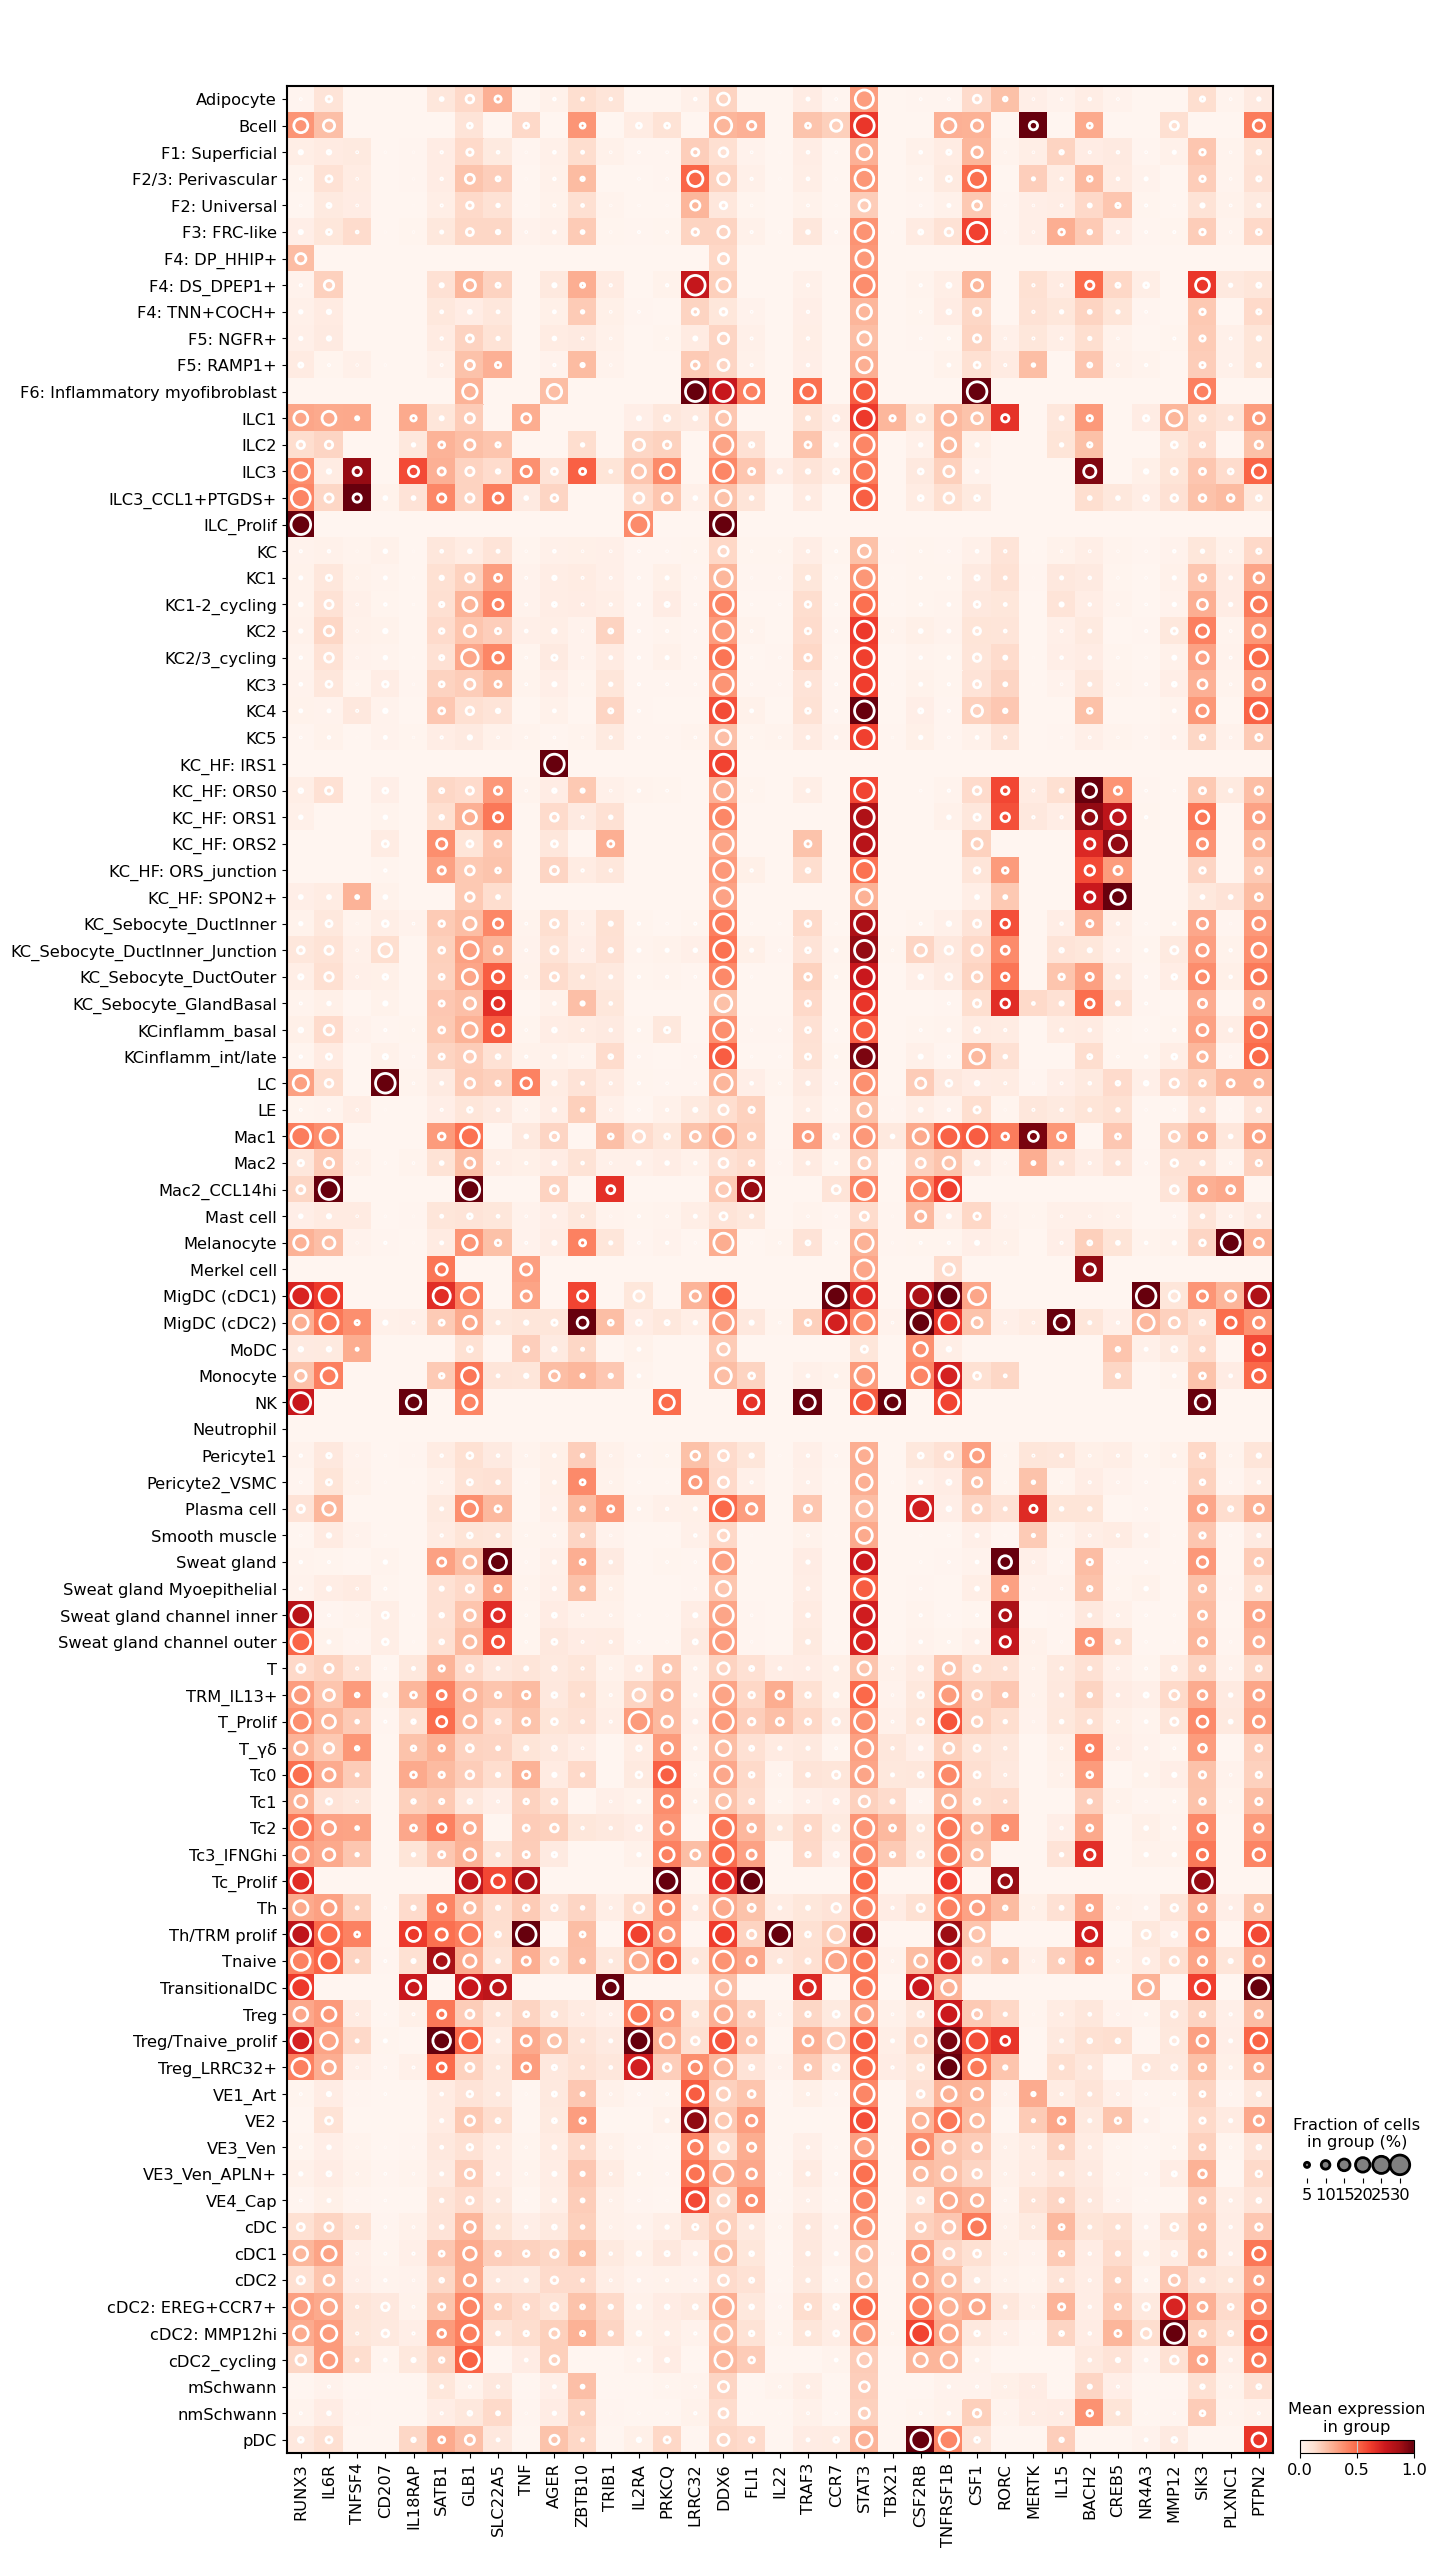

In [12]:
dp = sc.pl.DotPlot(
            adata_5k_ii, #[adata_5k_i.obs["Site_status_binary"]=="Lesional"],
            remove_markers(AD_GENES_OT),#[:40],
            #swap_axes=True,
            groupby="lvl5_annotation",
           vmax=1,
            #    colorbar_title='Mean expression\n(variance scaled)', 
         standard_scale="var",
           # save="5g_AD.pdf",
        ) 
dp = dp.style(cmap='Reds', color_on='square', dot_edge_color='white', dot_edge_lw=2, grid=False, #vmax=.8
                       dot_max=.3

                  )
#dp.show()     
dp.savefig("supp/supp_celltypes0HEATMAP_gwas_ad.pdf", dpi=300)       
    

# psoriasis GWAS

In [13]:
psoriasis_genes = [
    
    "IL23R",
    "FSD1",
    "FUT2",
    "STAP2",
    "CPVL",
    "POU2F3",
    "TRAF3IP2",
    "TYK2",
     "SH2B3",
    "ERAP1",
    "CARD14",
    
    
    "PARK7", "ERRFI1", "PLOD1", "RUNX3", "IL12RB2", "LCE3C", "KPRP", "CRB1",
    "PTPRC", "KDM5B", "CYB5R1", "POMC", "NRBP1", "PUS10", "C2ORF74", "AHSA2",
    "B3GNT2", "ACOXL", "KCNH7", "PLCL2", "CEP97", "ZPLD1", "LEKR1", "TP63",
    "CCNA2", "IL7R", "CAST", "HINT1", "SLC22A4", "CSF1R", "FGFR4", "IRF4",
    "CDKAL1", "SLC17A3", "SLC17A2", "PSMB9", "ITPR3", "GRM4", "BEND3", "FYN",
    "IFNGR1", "TAGAP", "ELMO1", "MYC", "ACO1", "DDX58", "NDUFB6", "FAM206A",
    "IL2RA", "PLAU", "ADK", "ZMIZ1", "PPIF", "PRR5L", "RPS6KA4", "ESRRA",
    "MAP3K11", "ZC3H12C", "GRIK4", "ETS1", "KCNJ1", "ERBB3", "COG6", "FOXO1",
    "PSMA6", "ATP10A", "KLF13", "CLEC16A", "RMI2", "CTD-3088G3.8", "ITGAX",
    "LGALS9", "KCNH4", "HSD17B1", "PHOSPHO1", "GALK1", "CARD14", "SGSH",
    "TUBB6", "PTPN2", "POLI", "STARD6", "TYK2", "S1PR5", "DNMT3B", "PTPN1",
    "IFNAR1", "RUNX1", "PPIL2"
]
seen=[]
newli=[]
for x in psoriasis_genes:
    if x not in seen:
        newli.append(x)
        seen.append(x)
    else:
        continue
psoriasis_genes=remove_markers(newli)



In [14]:
adata_5k_i=adata_5k[adata_5k.obs["disease_overall"]=="Psoriasis"]
adata_5k_i.shape

(398025, 4993)

In [15]:
adata_5k_i=adata_5k_i[adata_5k_i.obs["niche19"]!="Nonspecific/folded"]
adata_5k_i=adata_5k_i[~adata_5k_i.obs["niche19"].isna()]
adata_5k_ii=adata_5k_i[adata_5k_i.obs["Site_status"]=="Lesional"]


counts = adata_5k_ii.obs["niche19"].value_counts()
valid_niches = counts[counts > 10].index
dadata_5k_ii = adata_5k_ii[adata_5k_ii.obs["niche19"].isin(valid_niches)].copy()


In [16]:
# dp = sc.pl.DotPlot(
#         adata_5k_ii,
#         remove_markers(psoriasis_genes)[:40],
#         #swap_axes=True,
#         groupby="lvl5_annotation",
#        vmax=.6,
#         #    colorbar_title='Mean expression\n(variance scaled)', 
#    #  standard_scale="var",

#     ) 
# dp = dp.style(cmap='Reds', color_on='square', dot_edge_color='white', dot_edge_lw=2, grid=False, #vmax=.8
#                    dot_max=.3

#               )

# #dp.savefig("fig5/supp9c_spatial_gwas_pso_celltype.pdf", dpi=300)       
# dp.show()

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:731: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  

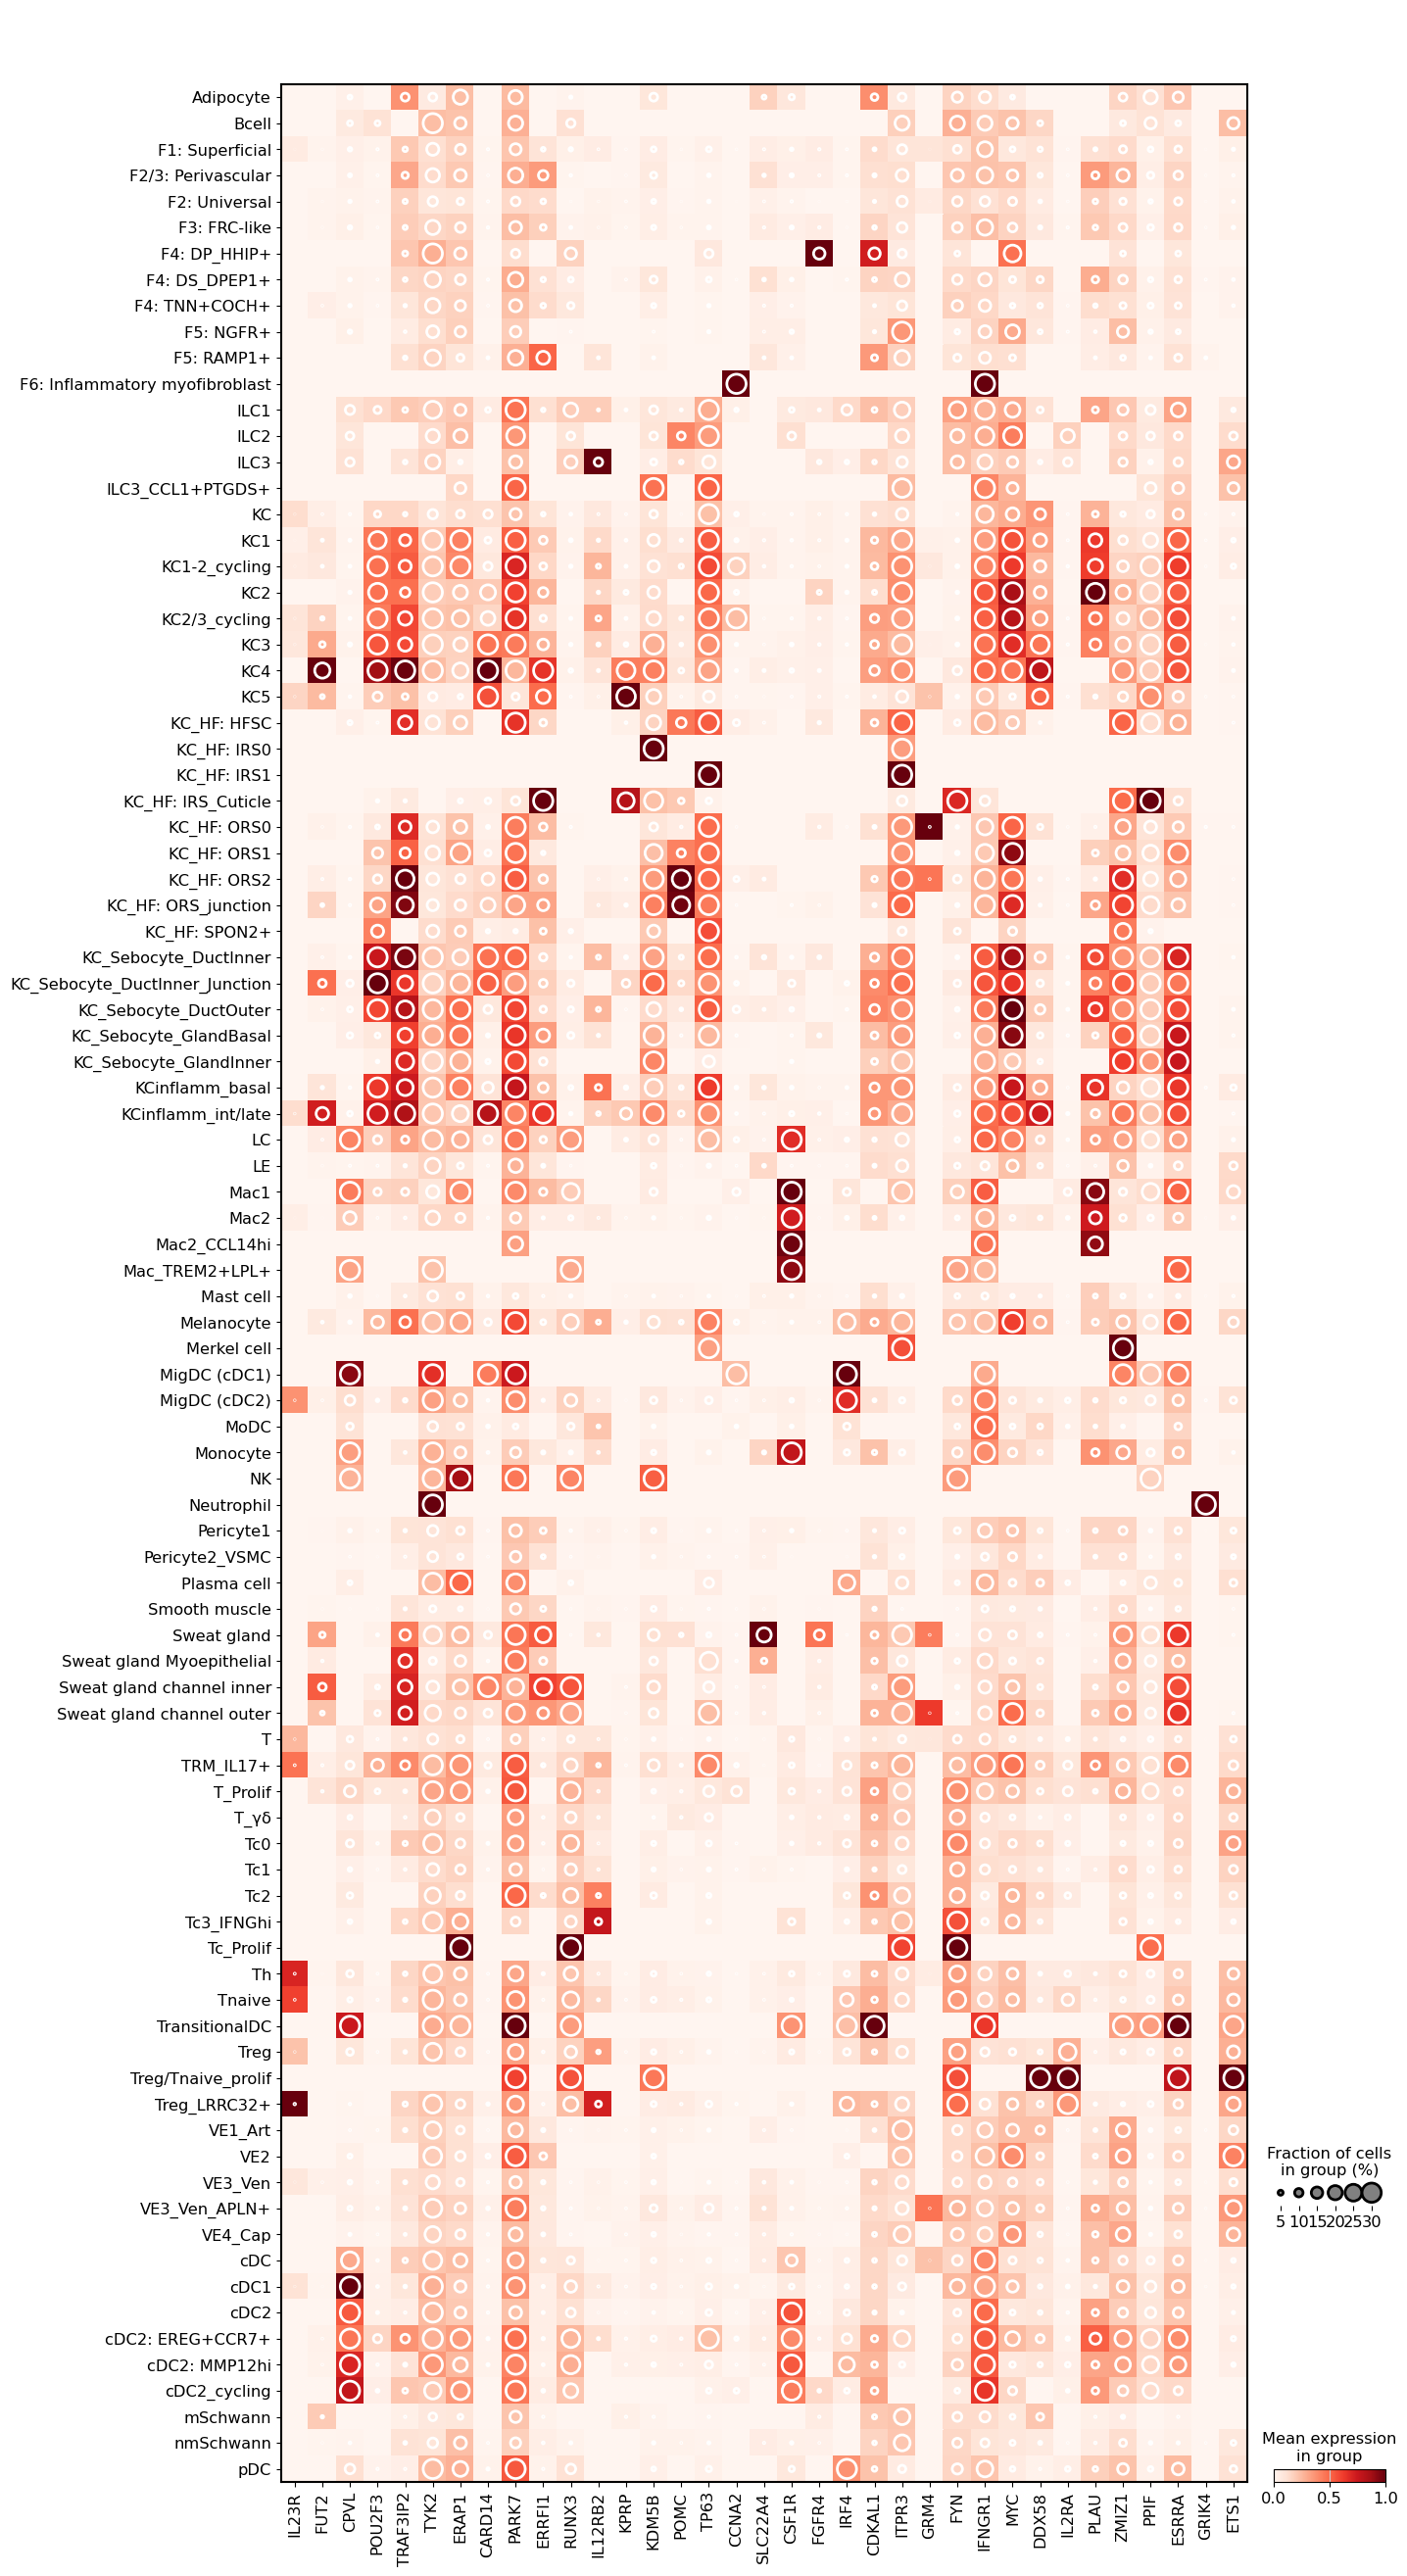

In [17]:
dp = sc.pl.DotPlot(
            adata_5k_ii, #[adata_5k_i.obs["Site_status_binary"]=="Lesional"],
            remove_markers(psoriasis_genes)[:35],
            #swap_axes=True,
            groupby="lvl5_annotation",
           vmax=1,
            #    colorbar_title='Mean expression\n(variance scaled)', 
         standard_scale="var",
           # save="5g_AD.pdf",
        ) 
dp = dp.style(cmap='Reds', color_on='square', dot_edge_color='white', dot_edge_lw=2, grid=False, #vmax=.8
                       dot_max=.3

                  )
#dp.show()     
dp.savefig("supp/supp_celltypes0HEATMAP_gwas_pso.pdf", dpi=300)       
    

In [18]:
# dp = sc.pl.DotPlot(
#             adata_5k_ii, #[adata_5k_i.obs["Site_status_binary"]=="Lesional"],
#             remove_markers(psoriasis_genes),#[:35],
#             #swap_axes=True,
#             groupby="lvl5_annotation",
#            vmax=1,
#             #    colorbar_title='Mean expression\n(variance scaled)', 
#          standard_scale="var",
#            # save="5g_AD.pdf",
#         ) 
# dp = dp.style(cmap='Reds', color_on='square', dot_edge_color='white', dot_edge_lw=2, grid=False, #vmax=.8
#                        dot_max=.3

#                   )
# #dp.show()     
# dp.savefig("supp_celltypes0HEATMAP_gwas_pso.pdf", dpi=300)       
    